In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load user clusters (from K-Means)
user_clusters = pd.read_csv('/content/drive/MyDrive/archive/user_clusters.csv')

print(f"Shape: {user_clusters.shape}")
print(f"Columns: {user_clusters.columns.tolist()}")
user_clusters.head()

Shape: (983, 7)
Columns: ['cc_num', 'total_spent', 'avg_transaction', 'num_transactions', 'std_transaction', 'unique_categories', 'cluster']


,cc_num,total_spent,avg_transaction,num_transactions,std_transaction,unique_categories,cluster
0,60416207185,85043.47,56.02,1518,122.63,14,0
1,60422928733,105640.20,69.00,1531,102.68,14,3
2,60423098130,58673.63,115.05,510,1202.99,14,1
3,60427851591,59129.61,111.99,528,143.31,14,1
4,60487002085,25160.11,50.73,496,65.84,14,1


In [4]:
# Load cleaned transaction data
df_train = pd.read_csv('/content/drive/MyDrive/archive/fraudTrain_cleaned.csv')

print(f"Transactions: {len(df_train)}")
print(f"Categories: {df_train['category'].nunique()}")
print(df_train['category'].unique())

Transactions: 1296675
Categories: 14
['misc_net' 'grocery_pos' 'entertainment' 'gas_transport' 'misc_pos'
 'grocery_net' 'shopping_net' 'shopping_pos' 'food_dining' 'personal_care'
 'health_fitness' 'travel' 'kids_pets' 'home']


In [5]:
# Calculate average monthly spending per category per user
df_train['datetime'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['year_month'] = df_train['datetime'].dt.to_period('M')

In [6]:
# Total spending per user per category (across all months)
user_category_spending = df_train.groupby(['cc_num', 'category'])['amt'].sum().unstack(fill_value=0)

In [7]:
# Count months per user
months_per_user = df_train.groupby('cc_num')['year_month'].nunique()

# Calculate MONTHLY average per category
user_monthly_category = user_category_spending.div(months_per_user, axis=0)

print(f"Shape: {user_monthly_category.shape}")
user_monthly_category.head()

Shape: (983, 14)


category,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
cc_num,,,,,,,,,,,,,,
60416207185,295.956667,130.775000,734.535556,148.378333,813.697778,235.663333,422.482778,370.662222,167.816667,268.831667,312.733889,195.317778,605.220000,22.565556
60422928733,380.970556,548.360000,562.317222,133.762222,818.892222,260.410556,567.427222,656.775556,224.322778,335.461667,335.361667,526.423889,490.686111,27.728333
60423098130,127.232222,124.926111,202.303889,2.070556,296.437222,94.931111,103.016667,152.327222,81.766667,63.414444,114.536111,292.386111,90.546111,1513.751667
60427851591,165.849444,84.888889,115.640000,63.470000,434.380556,141.720556,266.560000,124.572778,234.066667,90.846111,86.312222,527.781667,353.077222,595.812222
60487002085,83.102222,104.692222,202.108333,56.090556,223.785556,126.159444,121.724444,146.735556,10.670000,161.155000,45.422222,30.965000,80.240000,4.933333


In [8]:
# Define category constraints
# Some categories are essential (can't cut below a minimum)
# Some are flexible (can cut more)

CATEGORY_CONFIG = {
    'grocery_pos': {'min_pct': 0.70, 'priority': 'essential'},      # Can't cut more than 30%
    'grocery_net': {'min_pct': 0.70, 'priority': 'essential'},
    'gas_transport': {'min_pct': 0.60, 'priority': 'essential'},    # Can't cut more than 40%
    'health_fitness': {'min_pct': 0.50, 'priority': 'important'},
    'home': {'min_pct': 0.80, 'priority': 'essential'},             # Rent/utilities mostly fixed
    'kids_pets': {'min_pct': 0.60, 'priority': 'important'},
    'personal_care': {'min_pct': 0.50, 'priority': 'flexible'},
    'food_dining': {'min_pct': 0.30, 'priority': 'flexible'},       # Can cut significantly
    'entertainment': {'min_pct': 0.20, 'priority': 'flexible'},     # Most flexible
    'shopping_net': {'min_pct': 0.20, 'priority': 'flexible'},
    'shopping_pos': {'min_pct': 0.20, 'priority': 'flexible'},
    'travel': {'min_pct': 0.10, 'priority': 'flexible'},            # Can cut almost entirely
    'misc_net': {'min_pct': 0.30, 'priority': 'flexible'},
    'misc_pos': {'min_pct': 0.30, 'priority': 'flexible'}
}

print("Category Configuration:")
for cat, config in CATEGORY_CONFIG.items():
    print(f"  {cat}: min {config['min_pct']*100:.0f}%, priority: {config['priority']}")

Category Configuration:
  grocery_pos: min 70%, priority: essential
  grocery_net: min 70%, priority: essential
  gas_transport: min 60%, priority: essential
  health_fitness: min 50%, priority: important
  home: min 80%, priority: essential
  kids_pets: min 60%, priority: important
  personal_care: min 50%, priority: flexible
  food_dining: min 30%, priority: flexible
  entertainment: min 20%, priority: flexible
  shopping_net: min 20%, priority: flexible
  shopping_pos: min 20%, priority: flexible
  travel: min 10%, priority: flexible
  misc_net: min 30%, priority: flexible
  misc_pos: min 30%, priority: flexible


In [9]:
def optimize_budget_v3(current_spending, target_total, category_config):
    """
    Improved optimization: cuts are proportional to spending amount.
    Bigger flexible categories get bigger cuts.
    """

    categories = list(current_spending.keys())
    current_values = np.array([current_spending[cat] for cat in categories])
    current_total = current_values.sum()

    if target_total >= current_total:
        return current_spending, "No cuts needed"

    # Priority weights
    priority_weights = {
        'essential': 10.0,
        'important': 5.0,
        'flexible': 1.0
    }

    weights = np.array([
        priority_weights[category_config[cat]['priority']]
        for cat in categories
    ])

    # Normalize by current spending - this makes cuts PROPORTIONAL
    # Higher spending = more absolute cut, but same % cut within priority
    normalized_weights = weights / (current_values + 1)  # +1 to avoid division by zero

    def objective(x):
        return np.sum(normalized_weights * (x - current_values) ** 2)

    def constraint_total(x):
        return np.sum(x) - target_total

    bounds = []
    for cat in categories:
        min_val = current_spending[cat] * category_config[cat]['min_pct']
        max_val = current_spending[cat]
        bounds.append((min_val, max_val))

    reduction_ratio = target_total / current_total
    x0 = current_values * reduction_ratio

    result = minimize(
        objective,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints={'type': 'eq', 'fun': constraint_total},
        options={'maxiter': 1000}
    )

    optimized = {cat: result.x[i] for i, cat in enumerate(categories)}
    return optimized, result

In [10]:
# Test with a sample user
sample_user = user_monthly_category.iloc[0]
current_spending = sample_user.to_dict()

print("Sample User Current Monthly Spending:")
total_current = sum(current_spending.values())
print(f"Total: ${total_current:.2f}/month\n")

for cat, amt in sorted(current_spending.items(), key=lambda x: -x[1]):
    print(f"  {cat}: ${amt:.2f}")

Sample User Current Monthly Spending:
Total: $4724.64/month

  grocery_pos: $813.70
  gas_transport: $734.54
  shopping_pos: $605.22
  home: $422.48
  kids_pets: $370.66
  personal_care: $312.73
  entertainment: $295.96
  misc_pos: $268.83
  health_fitness: $235.66
  shopping_net: $195.32
  misc_net: $167.82
  grocery_net: $148.38
  food_dining: $130.77
  travel: $22.57


In [11]:
# Set target: Save $500/month
savings_goal = 500
target_total = total_current - savings_goal

print(f"Current spending: ${total_current:.2f}/month")
print(f"Savings goal: ${savings_goal:.2f}/month")
print(f"Target budget: ${target_total:.2f}/month")



Current spending: $4724.64/month
Savings goal: $500.00/month
Target budget: $4224.64/month


In [12]:
# Test v3 on sample user
optimized_v3, result_v3 = optimize_budget_v3(current_spending, target_total, CATEGORY_CONFIG)

print(f"{'='*70}")
print("PROPORTIONAL BUDGET CUTS (v3)")
print(f"{'='*70}\n")

print(f"{'Category':<20} {'Priority':<12} {'Current':>10} {'Optimized':>10} {'Cut $':>10} {'Cut %':>8}")
print("-" * 70)

total_optimized = 0
for cat in sorted(current_spending.keys(), key=lambda x: -current_spending[x]):
    curr = current_spending[cat]
    opt = optimized_v3[cat]
    change = curr - opt
    pct = (change / curr) * 100 if curr > 0 else 0
    priority = CATEGORY_CONFIG[cat]['priority']
    total_optimized += opt
    print(f"{cat:<20} {priority:<12} ${curr:>8.2f} ${opt:>8.2f} ${change:>8.2f} {pct:>7.1f}%")

print("-" * 70)
print(f"{'TOTAL':<20} {'':<12} ${total_current:>8.2f} ${total_optimized:>8.2f} ${total_current - total_optimized:>8.2f}")

PROPORTIONAL BUDGET CUTS (v3)

Category             Priority        Current  Optimized      Cut $    Cut %
----------------------------------------------------------------------
grocery_pos          essential    $  813.70 $  796.31 $   17.39     2.1%
gas_transport        essential    $  734.54 $  718.82 $   15.72     2.1%
shopping_pos         flexible     $  605.22 $  475.75 $  129.47    21.4%
home                 essential    $  422.48 $  413.44 $    9.04     2.1%
kids_pets            important    $  370.66 $  354.78 $   15.88     4.3%
personal_care        flexible     $  312.73 $  245.70 $   67.03    21.4%
entertainment        flexible     $  295.96 $  232.55 $   63.41    21.4%
misc_pos             flexible     $  268.83 $  211.24 $   57.59    21.4%
health_fitness       important    $  235.66 $  225.55 $   10.11     4.3%
shopping_net         flexible     $  195.32 $  153.36 $   41.95    21.5%
misc_net             flexible     $  167.82 $  131.78 $   36.04    21.5%
grocery_net        

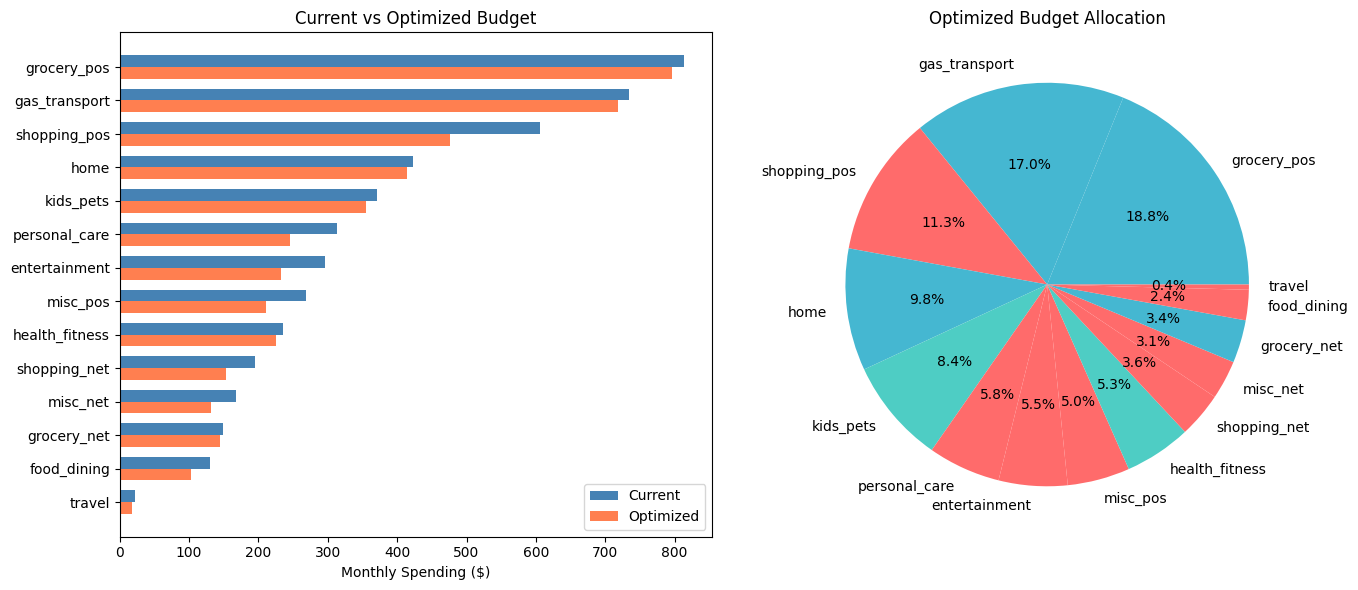

Legend: Blue=Essential, Teal=Important, Red=Flexible


In [13]:
# Visualization 1: Before vs After Budget
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = list(current_spending.keys())
current_vals = [current_spending[cat] for cat in categories]
optimized_vals = [optimized_v3[cat] for cat in categories]

# Sort by current spending
sorted_idx = np.argsort(current_vals)[::-1]
categories_sorted = [categories[i] for i in sorted_idx]
current_sorted = [current_vals[i] for i in sorted_idx]
optimized_sorted = [optimized_vals[i] for i in sorted_idx]

# Bar chart comparison
x = np.arange(len(categories_sorted))
width = 0.35

axes[0].barh(x - width/2, current_sorted, width, label='Current', color='steelblue')
axes[0].barh(x + width/2, optimized_sorted, width, label='Optimized', color='coral')
axes[0].set_yticks(x)
axes[0].set_yticklabels(categories_sorted)
axes[0].set_xlabel('Monthly Spending ($)')
axes[0].set_title('Current vs Optimized Budget')
axes[0].legend()
axes[0].invert_yaxis()

# Pie chart of optimized budget
colors = ['#ff6b6b' if CATEGORY_CONFIG[cat]['priority'] == 'flexible'
          else '#4ecdc4' if CATEGORY_CONFIG[cat]['priority'] == 'important'
          else '#45b7d1' for cat in categories_sorted]

axes[1].pie(optimized_sorted, labels=categories_sorted, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Optimized Budget Allocation')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/slsqp_budget_comparison.png', dpi=150)
plt.show()

print("Legend: Blue=Essential, Teal=Important, Red=Flexible")

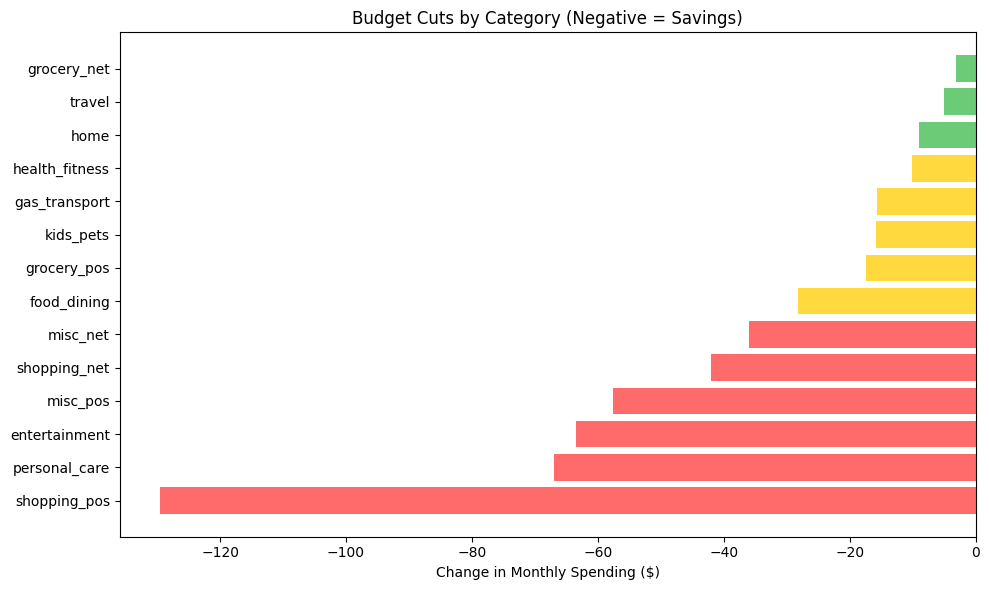


Total Savings: $500.00/month


In [14]:
# Visualization 2: Savings by Category
changes = {cat: optimized_v3[cat] - current_spending[cat] for cat in categories}
changes_sorted = dict(sorted(changes.items(), key=lambda x: x[1]))

plt.figure(figsize=(10, 6))
colors = ['#ff6b6b' if v < -30 else '#ffd93d' if v < -10 else '#6bcb77' for v in changes_sorted.values()]
plt.barh(list(changes_sorted.keys()), list(changes_sorted.values()), color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Change in Monthly Spending ($)')
plt.title('Budget Cuts by Category (Negative = Savings)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/slsqp_savings_by_category.png', dpi=150)
plt.show()

print(f"\nTotal Savings: ${sum(changes.values()) * -1:.2f}/month")

In [15]:
# Update the generate_budget_recommendation function to use v3
def generate_budget_recommendation(user_id, savings_goal, user_monthly_category, category_config):
    """
    Generate personalized budget recommendation for any user using v3 optimizer.
    """
    user_spending = user_monthly_category.loc[user_id].to_dict()
    current_total = sum(user_spending.values())
    target_total = current_total - savings_goal

    # Use v3 optimizer
    optimized, result = optimize_budget_v3(user_spending, target_total, category_config)

    recommendations = []
    for cat in sorted(user_spending.keys(), key=lambda x: optimized[x] - user_spending[x]):
        change = optimized[cat] - user_spending[cat]
        if change < -1:
            pct_change = (change / user_spending[cat]) * 100
            recommendations.append({
                'category': cat,
                'current': user_spending[cat],
                'recommended': optimized[cat],
                'savings': -change,
                'pct_cut': -pct_change
            })

    return {
        'user_id': user_id,
        'current_total': current_total,
        'target_total': target_total,
        'savings_goal': savings_goal,
        'optimized_spending': optimized,
        'recommendations': recommendations
    }

In [16]:
# Test with a different user
test_user_id = user_monthly_category.index[5]  # Pick 6th user
result = generate_budget_recommendation(test_user_id, 300, user_monthly_category, CATEGORY_CONFIG)

print(f"User: {result['user_id']}")
print(f"Current Total: ${result['current_total']:.2f}/month")
print(f"Savings Goal: ${result['savings_goal']:.2f}/month")
print(f"Target Budget: ${result['target_total']:.2f}/month")
print(f"\n{'='*50}")
print("TOP RECOMMENDATIONS TO SAVE MONEY:")
print(f"{'='*50}\n")

for i, rec in enumerate(result['recommendations'][:5], 1):
    print(f"{i}. Cut {rec['category']}")
    print(f"   Current: ${rec['current']:.2f} → Recommended: ${rec['recommended']:.2f}")
    print(f"   Save: ${rec['savings']:.2f}/month ({rec['pct_cut']:.1f}% reduction)\n")

User: 60490596305
Current Total: $4085.08/month
Savings Goal: $300.00/month
Target Budget: $3785.08/month

TOP RECOMMENDATIONS TO SAVE MONEY:

1. Cut shopping_net
   Current: $508.52 → Recommended: $443.00
   Save: $65.52/month (12.9% reduction)

2. Cut misc_net
   Current: $388.55 → Recommended: $338.44
   Save: $50.10/month (12.9% reduction)

3. Cut shopping_pos
   Current: $369.96 → Recommended: $322.26
   Save: $47.70/month (12.9% reduction)

4. Cut misc_pos
   Current: $242.12 → Recommended: $210.86
   Save: $31.27/month (12.9% reduction)

5. Cut entertainment
   Current: $205.83 → Recommended: $179.23
   Save: $26.60/month (12.9% reduction)



In [17]:
# Save the optimization configuration
import joblib

# Save category config
joblib.dump(CATEGORY_CONFIG, '/content/drive/MyDrive/archive/slsqp_category_config.pkl')

# Save user monthly spending data
user_monthly_category.to_csv('/content/drive/MyDrive/archive/user_monthly_spending.csv')

print("Saved:")
print("  - slsqp_category_config.pkl")
print("  - user_monthly_spending.csv")

Saved:
  - slsqp_category_config.pkl
  - user_monthly_spending.csv


In [18]:
# Test on 3 different users with different savings goals
print("="*70)
print("BUDGET OPTIMIZATION EXAMPLES")
print("="*70)

test_cases = [
    (user_monthly_category.index[0], 500),   # User 1: Save $500
    (user_monthly_category.index[10], 200),  # User 2: Save $200
    (user_monthly_category.index[50], 1000), # User 3: Save $1000
]

for user_id, savings in test_cases:
    result = generate_budget_recommendation(user_id, savings, user_monthly_category, CATEGORY_CONFIG)
    print(f"\nUser: {user_id}")
    print(f"Current: ${result['current_total']:.2f} → Target: ${result['target_total']:.2f} (Save ${savings})")
    print("Top 3 cuts:")
    for rec in result['recommendations'][:3]:
        print(f"  - {rec['category']}: Save ${rec['savings']:.2f} ({rec['pct_cut']:.1f}%)")

BUDGET OPTIMIZATION EXAMPLES

User: 60416207185
Current: $4724.64 → Target: $4224.64 (Save $500)
Top 3 cuts:
  - shopping_pos: Save $129.47 (21.4%)
  - personal_care: Save $67.03 (21.4%)
  - entertainment: Save $63.41 (21.4%)

User: 501831082224
Current: $3493.05 → Target: $3293.05 (Save $200)
Top 3 cuts:
  - misc_net: Save $33.88 (10.9%)
  - personal_care: Save $33.11 (10.9%)
  - shopping_net: Save $32.77 (10.9%)

User: 639023984367
Current: $8666.69 → Target: $7666.69 (Save $1000)
Top 3 cuts:
  - shopping_pos: Save $163.45 (21.6%)
  - travel: Save $136.66 (21.7%)
  - misc_net: Save $115.99 (21.6%)


In [21]:
# Test on 10 different users with same savings goal - SHOW ALL CUTS
print("="*70)
print("TESTING SAME SAVINGS GOAL ($500) ON 10 DIFFERENT USERS")
print("="*70)

for i in [0, 5, 10, 20, 50, 100, 200, 300, 500, 800]:
    user_id = user_monthly_category.index[i]
    result = generate_budget_recommendation(user_id, 500, user_monthly_category, CATEGORY_CONFIG)

    print(f"\nUser {i}: {user_id}")
    print(f"Current: ${result['current_total']:.2f}")
    print("All cuts:")
    for rec in result['recommendations']:
        print(f"  - {rec['category']}: ${rec['current']:.2f} → ${rec['recommended']:.2f} | Save ${rec['savings']:.2f} ({rec['pct_cut']:.1f}%)")

TESTING SAME SAVINGS GOAL ($500) ON 10 DIFFERENT USERS

User 0: 60416207185
Current: $4724.64
All cuts:
  - shopping_pos: $605.22 → $475.75 | Save $129.47 (21.4%)
  - personal_care: $312.73 → $245.70 | Save $67.03 (21.4%)
  - entertainment: $295.96 → $232.55 | Save $63.41 (21.4%)
  - misc_pos: $268.83 → $211.24 | Save $57.59 (21.4%)
  - shopping_net: $195.32 → $153.36 | Save $41.95 (21.5%)
  - misc_net: $167.82 → $131.78 | Save $36.04 (21.5%)
  - food_dining: $130.77 → $102.63 | Save $28.14 (21.5%)
  - grocery_pos: $813.70 → $796.31 | Save $17.39 (2.1%)
  - kids_pets: $370.66 → $354.78 | Save $15.88 (4.3%)
  - gas_transport: $734.54 → $718.82 | Save $15.72 (2.1%)
  - health_fitness: $235.66 → $225.55 | Save $10.11 (4.3%)
  - home: $422.48 → $413.44 | Save $9.04 (2.1%)
  - travel: $22.57 → $17.53 | Save $5.03 (22.3%)
  - grocery_net: $148.38 → $145.19 | Save $3.19 (2.2%)

User 5: 60490596305
Current: $4085.08
All cuts:
  - shopping_net: $508.52 → $399.32 | Save $109.20 (21.5%)
  - misc_

In [22]:
# Test different savings goals on SAME user - SHOW ALL CUTS
print("\n" + "="*70)
print("TESTING DIFFERENT SAVINGS GOALS ON SAME USER")
print("="*70)

user_id = user_monthly_category.index[0]
print(f"User: {user_id}")

for savings in [100, 300, 500, 800, 1000]:
    result = generate_budget_recommendation(user_id, savings, user_monthly_category, CATEGORY_CONFIG)

    print(f"\n--- Save ${savings} ---")
    for rec in result['recommendations']:
        print(f"  - {rec['category']}: {rec['pct_cut']:.1f}% cut (${rec['savings']:.2f})")


TESTING DIFFERENT SAVINGS GOALS ON SAME USER
User: 60416207185

--- Save $100 ---
  - shopping_pos: 4.3% cut ($25.89)
  - personal_care: 4.3% cut ($13.43)
  - entertainment: 4.3% cut ($12.69)
  - misc_pos: 4.3% cut ($11.49)
  - shopping_net: 4.3% cut ($8.37)
  - misc_net: 4.3% cut ($7.23)
  - food_dining: 4.3% cut ($5.62)
  - grocery_pos: 0.4% cut ($3.48)
  - kids_pets: 0.9% cut ($3.17)
  - gas_transport: 0.4% cut ($3.14)
  - health_fitness: 0.9% cut ($2.02)
  - home: 0.4% cut ($1.81)
  - travel: 4.5% cut ($1.01)

--- Save $300 ---
  - shopping_pos: 12.8% cut ($77.68)
  - personal_care: 12.9% cut ($40.22)
  - entertainment: 12.9% cut ($38.05)
  - misc_pos: 12.9% cut ($34.56)
  - shopping_net: 12.9% cut ($25.17)
  - misc_net: 12.9% cut ($21.62)
  - food_dining: 12.9% cut ($16.89)
  - grocery_pos: 1.3% cut ($10.43)
  - kids_pets: 2.6% cut ($9.53)
  - gas_transport: 1.3% cut ($9.43)
  - health_fitness: 2.6% cut ($6.06)
  - home: 1.3% cut ($5.43)
  - travel: 13.4% cut ($3.02)
  - grocery_